<a href="https://colab.research.google.com/github/Filoferro03/LabDataIntensivePredizioneBorsa/blob/main/Predizione_Indice_Borsa/Predizione_Indice_Borsa.nosol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio: Predizione di un Indice di Borsa

**Programmazione di Applicazioni Data Intensive**  
Laurea in Ingegneria e Scienze Informatiche  
DISI - Università di Bologna, Cesena

Proff. Gianluca Moro, Roberto Pasolini  
`nome.cognome@unibo.it`

## Setup

Importare le librerie necessarie

In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
%matplotlib inline

## Predizione di un indice di borsa

Un _indice_ in borsa è la sintesi del valore di diversi titoli azionari (_componenti_): il suo valore è una media (di solito ponderata) dei valori dei singoli titoli

In questa esercitazione consideriamo l'indice _Standard & Poor 500_ (S&P 500), che ha per componenti [circa 500 grandi aziende degli USA](https://en.wikipedia.org/wiki/List_of_S%26P_500_companies), incluse ad es. Alphabet (Google), Facebook, Apple, ...

L'obiettivo è generare modelli in grado di **prevedere le variazioni** dell'indice S&P 500, in modo da **massimizzare il guadagno** ottenuto investendo in un fondo che si basa su tale indice

## Estrazione dati

I dati storici sull'andamento di S&P 500 e altri indici e titoli di borsa sono disponibili su diversi siti specializzati, ad es. [Yahoo! Finance](https://finance.yahoo.com/)

Dal sito è possibile interattivamente ricercare titoli e indici e consultarne i dati attuali e storici, scaricandoli eventualmente in formato CSV

È però spesso possibile estrarre i dati forniti anche tramite codice, effettuando opportune operazioni per importarli in strutture dati appropriate

Esistono alcune librerie che forniscono funzioni di alto livello per importare dati da Yahoo! Finance e altri fonti simili: queste gestiscono automaticamente il reperimento dei dati dagli URL corretti ed il loro parsing

### yfinance

[yfinance](https://pypi.org/project/yfinance/) è una libreria per l'estrazione di dati da Yahoo! Finance in forma di oggetti Python facilmente interrogabili

In particolare, la usiamo per ottenere i dati storici di titoli e indici in forma di DataFrame pandas

Eseguire la seguente cella di codice per installare yfinance (e il package lxml necessario) nell'ambiente virtuale in uso _(nel caso di problemi con la libreria, i dati necessari per l'esercitazione sono disponibili anche in un file indicato sotto)_

In [155]:
pip install yfinance lxml

Importare il modulo `yfinance`, verificandone così la corretta installazione

In [156]:
import yfinance

Per usare il modulo creiamo un oggetto `Ticker`, che rappresenta uno specifico titolo o indice

Dobbiamo indicare il _simbolo_ del titolo o indice con cui vogliamo lavorare, che per S&P 500 è `^GSPC`

In [157]:
sp500 = yfinance.Ticker("^GSPC")

Altri simboli di indici noti includono:

- `^DJI`: Dow Jones Industrial Average
- `^IXIC`: NASDAQ
- `FTSEMIB.MI`: MIB (borsa di Milano)

Da un `Ticker` possiamo usare il metodo `history` per ottenere un frame con i dati storici in un periodo specificato

- con `start` e `end` specifichiamo l'intervallo di date desiderato
- `actions=False` esclude alcune colonne con dati non disponibili per l'indice

Scarichiamo i dati relativi agli anni dal 2001 al 2008

In [158]:
data = sp500.history(start="2001-01-01", end="2008-12-31", actions=False)

_In caso di problemi con yfinance, decommentare ed eseguire la seguente cella per importare gli stessi dati da un file già scaricato da noi_

In [159]:
# data = pd.read_csv("https://git.io/Jfq8p", index_col="Date", parse_dates=["Date"])

In [160]:
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2001-01-02 00:00:00-05:00,1320.280029,1320.280029,1276.050049,1283.270020,1129400000
2001-01-03 00:00:00-05:00,1283.270020,1347.760010,1274.619995,1347.560059,1880700000
2001-01-04 00:00:00-05:00,1347.560059,1350.239990,1329.140015,1333.339966,2131000000
2001-01-05 00:00:00-05:00,1333.339966,1334.770020,1294.949951,1298.349976,1430800000
2001-01-08 00:00:00-05:00,1298.349976,1298.349976,1276.290039,1295.859985,1115500000


- Ciascuna riga corrisponde ad una data, indicata nell'indice `Date`
  - non sono presenti le righe relative a giorni di chiusura del mercato
- `Open` e `Close` riportano per ogni data il valore dell'indice all'apertura e alla chiusura del mercato
- `High` e `Low` riportano i massimi e minimi giornalieri
- `Volume` è il numero di titoli scambiati in giornata

Per comodità, estraiamo una serie per ciascuna colonna, per potersi riferire ad esse con un unico nome

_(notare che la serie `open` sovrascrive la funzione `open` di Python, quest'ultima se necessaria rimane accessibile come `__builtins__.open`)_

In [161]:
open = data["Open"]
high = data["High"]
low = data["Low"]
close = data["Close"]
volume = data["Volume"]

Possiamo tracciare un grafico dell'andamento del titolo, prendendo come riferimento ad es. il valore dell'apertura

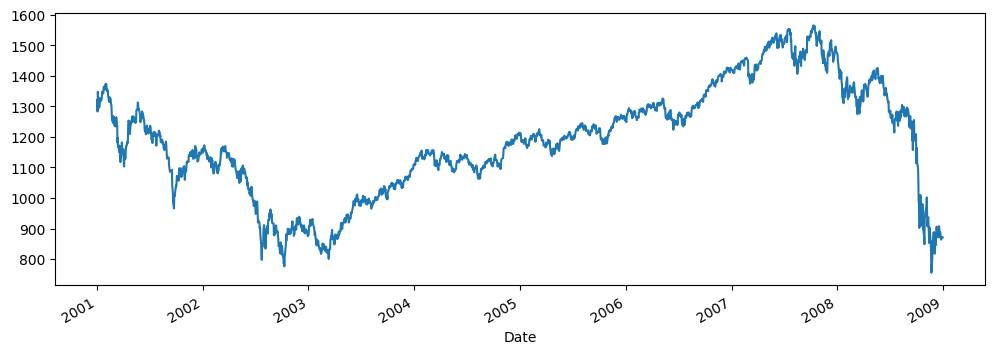

In [162]:
open.plot(figsize=(12, 4));

Esistono altri tipi di grafici appositi per mostrare l'andamento di titoli di borsa, ad es. i _candlestick chart_ ("grafici a candela"), per disegnarli si veda la libreria `mplfinance`, estensione di matplotlib

### Esercizio 1: Analisi esplorativa

- **(1a)** Estrarre le statistiche principali (media, dev. standard, ...) delle varie colonne (Open, Close, ...)
- **(1b)** Ottenere una serie `hlm` col valore medio tra il massimo e il minimo giornalieri
- **(1c)** Estrarre le statistiche principali di tale serie
- **(1d)** Estrarre le statistiche principali di `hlm` suddivise per anno

In [163]:
data.describe()

,Open,High,Low,Close,Volume
count,2010.000000,2010.000000,2010.000000,2010.000000,2.010000e+03
mean,1187.474553,1195.450877,1178.652866,1187.302095,2.257390e+09
std,180.326713,179.563836,181.296274,180.433599,1.379745e+09
min,755.840027,798.549988,741.020020,752.440002,3.560700e+08
25%,1084.077454,1091.872528,1075.594971,1083.882446,1.359225e+09
50%,1190.229980,1195.979980,1183.635010,1190.229980,1.693850e+09
75%,1304.137512,1311.609985,1295.272522,1304.324982,2.696278e+09
max,1564.979980,1576.089966,1555.459961,1565.150024,1.145623e+10


In [164]:
hlm = (high + low) / 2
print(hlm.describe())

count    2010.000000
mean     1187.051872
std       180.340289
min       771.110016
25%      1084.422501
50%      1189.442474
75%      1303.409988
max      1561.404968
dtype: float64


In [165]:
hlm.groupby(hlm.index.year).describe()

,count,mean,std,min,25%,50%,75%,max
Date,,,,,,,,
2001,248.0,1193.689196,86.865939,964.644989,1136.603775,1191.602539,1254.802490,1374.015015
2002,252.0,993.878335,114.077936,787.174988,895.336250,968.600006,1107.357483,1170.260010
2003,252.0,964.632222,78.602540,796.545013,896.213753,985.644989,1028.395004,1109.385010
2004,252.0,1130.409743,31.444939,1064.149963,1110.626266,1126.692505,1142.978729,1214.940002
2005,252.0,1207.289366,29.553492,1144.360046,1187.330002,1204.835022,1228.238770,1271.455017
2006,251.0,1310.053308,50.920535,1225.375000,1273.427521,1296.955017,1336.912506,1428.554993
2007,251.0,1476.593744,44.426483,1376.034973,1442.607483,1475.619995,1512.577515,1561.404968
2008,252.0,1221.611490,190.555138,771.110016,1150.651276,1289.319977,1359.184998,1456.919983


## Obiettivo: prevedere il valore di chiusura a inizio giornata

Assumiamo che un agente investa quotidianamente sull'indice S&P 500

Per investire in modo ottimale vogliamo addestrare un modello a **prevedere all'inizio di ogni giornata** `d` il valore `close[d]` dell'indice **a fine giornata**

La variabile `close` è quindi quella da prevedere, la _y_

In [166]:
y = close

Quali sono le variabili predittive, le _X_?

`high`, `low` e `volume` **non possono essere utilizzate** in quanto il loro valore **non è noto** a inizio giornata

Solamente il valore `open[d]` è noto al momento della predizione

Iniziamo creando un modello di predizione solamente sulla variabile `open`

Creiamo un dizionario `features` con le variabili predittive, in questo caso solamente il valore di `open`

In [167]:
features = {"Open": open}

Incapsuliamo le variabili in un `DataFrame`

In [168]:
X = pd.DataFrame(features)

In [169]:
X.head(3)

,Open
Date,
2001-01-02 00:00:00-05:00,1320.280029
2001-01-03 00:00:00-05:00,1283.270020
2001-01-04 00:00:00-05:00,1347.560059


### Suddivisione dati

Effettuiamo una prima suddivisione dei dati in training e validation set

Avendo una serie temporale, è comune utilizzare come training i dati fino ad una data specifica e come validation quelli successivi

Definiamo una funzione `split_before_2005` che, dati `X` e `y`, restituisca in una tupla con 4 elementi

- un training set `X_train` e `y_train` con i dati fino al 2004
- un validation set `X_val` e `y_val` con i dati dal 2005 in poi

Utilizziamo tale funzione per suddividere i dati `X` e `y` definiti sopra

In [170]:
def split_before_2005(X, y):
    is_train = X.index.year < 2005
    X_train = X.loc[is_train]
    y_train = y.loc[is_train]
    X_val = X.loc[~is_train]
    y_val = y.loc[~is_train]
    return X_train, X_val, y_train, y_val

In [171]:
X_train, X_val, y_train, y_val = split_before_2005(X, y)

### Esercizio 2: Addestramento e validazione modelli

Usando training e validation set creati sopra, addestrare ciascuno dei seguenti modelli ed ottenerne il coefficiente R²
- **(2a)** regressione lineare semplice
- **(2b)** regressione polinomiale di grado 10 con regolarizzazione L2 ($\alpha=1$)
- **(2c)** regressione polinomiale di grado 3 con standardizzazione delle feature

In [172]:
# import necessari
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

In [173]:
# (2a) regressione lineare semplice
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
model_lr.score(X_val, y_val)

0.9886049726011812

In [174]:
# prompt:  regressione polinomiale di grado 10 con regolarizzazione L2 ( α=1 )

# (2b) regressione polinomiale di grado 10 con regolarizzazione L2 (α=1)
model_pr = Pipeline([
    ("poly", PolynomialFeatures(degree=5, include_bias=False)),
    ("ridge", Ridge(alpha=1))
])
model_pr.fit(X_train, y_train)
model_pr.score(X_val, y_val)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.40055e-33): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


0.9824657739540624

In [175]:
# prompt: regressione polinomiale di grado 3 con standardizzazione delle feature

# (2c) regressione polinomiale di grado 3 con standardizzazione delle feature
model_pr3 = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])
model_pr3.fit(X_train, y_train)
model_pr3.score(X_val, y_val)

0.9847818325593015

## Simulazione di trading

I punteggi R² dei modelli (anche i più semplici) risultano molto alti

Questo è dovuto al fatto che i valori di `open` e `close` sono generalmente molto correlati

Tuttavia, questo non indica quanto il modello sia in grado di cogliere le piccole variazioni giornaliere tra i due, che sono determinanti nel guidare un investitore

Per avere un'idea dell'utilità effettiva del modello, calcoliamo il **guadagno effettivo** che avrebbe un investitore utilizzando il modello

### Protocollo di trading

Assumiamo un investitore che

- all'inizio di ogni giornata $d$ confronta il valore di apertura noto $O_d$ col valore di chiusura predetto dal modello $\hat{C}_d$
- se è previsto un rialzo ($\hat{C}_d > O_d$), compra un titolo e lo rivende a fine giornata, con un guadagno di $C_d-O_d$
- se è previsto un ribasso ($\hat{C}_d < O_d$) vende (allo scoperto) un titolo e lo ricompra a fine giornata, con un guadagno di $O_d-C_d$ (l'opposto del primo caso)

Possiamo definire una metrica "guadagno" per validare il modello, che restituisca il guadagno totale di un investitore che opera nel periodo a cui si riferisce il validation set

### Esercizio 3: Implementazione protocollo di trading

Completare l'implementazione di `gain` in modo che, date le serie di valori di chiusura reali `C` e predetti `C_pred`, restituisca il guadagno di un investitore secondo le specifiche sopra
- la serie di valori di apertura `O` è ricavata dalla serie completa `open` usando `reindex_like` per selezionare esattamente le date di `C`
- definire la serie `CO_diff` come la differenza $C_d-O_d$
- definire le serie booleane `growth` e `decline` che indicano in quali giorni viene *previsto* un rialzo o un ribasso del valore
- restituire la somma dei guadagni ottenuti da acquisto+vendita nei giorni `growth` e vendita+acquisto nei giorni `decline`

In [176]:
def gain(C, C_pred):
    O = open.reindex_like(C)
    CO_diff = C-O
    growth = C_pred > O
    decline = C_pred < O
    return CO_diff[growth].sum() -CO_diff[decline].sum()

### Calcolo del ROI

Il ROI (_Return on Investment_) esprime il guadagno di una o più operazioni in borsa in rapporto all'investimento iniziale

La cifra investita in questo caso è pari al valore d'apertura del titolo che varia giornalmente

Per stimare il ROI usiamo la media di tale valore nel periodo di investimento

Definiamo una nuova funzione `roi`, che riusa il guadagno `gain` definito sopra e lo rapporta all'investimento medio

In [177]:
def roi(C, C_pred):
    mean_open = open.reindex_like(C).mean()
    return gain(C, C_pred) / mean_open

Definiamo una funzione `print_eval` per stampare le metriche di valutazione del modello

Come le altre volte, dato il validation set e un modello da validare, si ottengono le predizioni e le si usano per calcolare le metriche; questa volta però mostriamo guadagno e ROI al posto delle metriche ordinarie

In [178]:
def print_eval(X, y, model):
    preds = model.predict(X)
    print("Gain: {:.2f}$".format(gain(y, preds)))
    print(" ROI: {:.3%}".format(roi(y, preds)))

Valutiamo ad esempio guadagno e ROI su un modello di regressione lineare semplice: si ottiene un ROI basso, intorno al 5\%

In [179]:
model = LinearRegression()
model.fit(X_train, y_train)
print_eval(X_val, y_val, model)

Gain: 61.36$
 ROI: 4.705%


## Introduzione di nuove feature

Abbiamo addestrato un modello a prevedere il valore giornaliero di chiusura $C_d$ a partire da quello di apertura corrispondente $O_d$

Abbiamo però visto con la stima di guadagno e ROI che tale modello non è efficace

Per ottenere predizioni più affidabili per ciascuna giornata $d$, possiamo però integrare **informazioni note dai giorni precedenti** a $d$

Vediamo come aggiungere tali informazioni in **nuove variabili** su cui basare le predizioni

Le serie forniscono il metodo `shift`, con cui è possibile ottenerne i **valori slittati in avanti** di un numero di posizioni dato

Data ad esempio la serie `open`...

In [180]:
open   .head(4)

,Open
Date,
2001-01-02 00:00:00-05:00,1320.280029
2001-01-03 00:00:00-05:00,1283.270020
2001-01-04 00:00:00-05:00,1347.560059
2001-01-05 00:00:00-05:00,1333.339966


...con `shift(2)` otteniamo gli stessi dati slittati in avanti di 2 giorni

In [181]:
open.shift(2)   .head(4)

,Open
Date,
2001-01-02 00:00:00-05:00,NaN
2001-01-03 00:00:00-05:00,NaN
2001-01-04 00:00:00-05:00,1320.280029
2001-01-05 00:00:00-05:00,1283.270020


Nei primi 2 giorni sono inseriti valori NaN, non essendo noti i valori dei giorni precedenti

Possiamo usare `shift` per generare le variabili che si riferiscono ai dati dei giorni precedenti

Definiamo ad esempio un nuovo insieme di feature dove, al valore di apertura del giorno corrente $O_d$, aggiungiamo quelli dei due giorni precedenti $O_{d-1}$ e $O_{d-2}$

In [182]:
features = {
    "Open": open,
    "OpenLag1": open.shift(1),
    "OpenLag2": open.shift(2),
}

Come sopra, creiamo un frame con i dati derivanti da tali feature

In [183]:
X = pd.DataFrame(features)

In [184]:
X.head(5)

,Open,OpenLag1,OpenLag2
Date,,,
2001-01-02 00:00:00-05:00,1320.280029,NaN,NaN
2001-01-03 00:00:00-05:00,1283.270020,1320.280029,NaN
2001-01-04 00:00:00-05:00,1347.560059,1283.270020,1320.280029
2001-01-05 00:00:00-05:00,1333.339966,1347.560059,1283.270020
2001-01-08 00:00:00-05:00,1298.349976,1333.339966,1347.560059


Otteniamo così un frame con tre variabili invece di una, ma nelle prime righe abbiamo dei valori mancanti

Utilizziamo il metodo `dropna` per eliminare tutte le righe con uno o più valori mancanti

In [185]:
X = pd.DataFrame(features).dropna()

In [186]:
X.head(5)

,Open,OpenLag1,OpenLag2
Date,,,
2001-01-04 00:00:00-05:00,1347.560059,1283.270020,1320.280029
2001-01-05 00:00:00-05:00,1333.339966,1347.560059,1283.270020
2001-01-08 00:00:00-05:00,1298.349976,1333.339966,1347.560059
2001-01-09 00:00:00-05:00,1295.859985,1298.349976,1333.339966
2001-01-10 00:00:00-05:00,1300.800049,1295.859985,1298.349976


Ora tutte le righe di `X` sono utilizzabili per addestrare e validare il modello

Avendo filtrato le righe di `X` dobbiamo filtrare allo stesso modo anche `y`: utilizziamo `reindex_like` per selezionare le stesse etichette (ovvero le date) nella serie `close`

In [187]:
y = close.reindex_like(X)

In [188]:
y.head(5)

,Close
Date,
2001-01-04 00:00:00-05:00,1333.339966
2001-01-05 00:00:00-05:00,1298.349976
2001-01-08 00:00:00-05:00,1295.859985
2001-01-09 00:00:00-05:00,1300.800049
2001-01-10 00:00:00-05:00,1313.270020


Riutilizziamo `split_before_2005` su `X` e `y` aggiornati per ottenere i training e validation set aggiornati

In [189]:
X_train, X_val, y_train, y_val = split_before_2005(X, y)

### Esercizio 4: Funzione per la generazione di training e validation set

Creare una funzione `prepare_data` che automatizzi i passaggi sopra

- accettare in input un dizionario di variabili predittive `features` (simile a quello sopra) e una variabile da predire `target`
- creare il frame `X` con le variabili predittive rimuovendo le righe con valori mancanti
- creare la serie `y` con i valori della variabile da predire corrispondenti alle righe selezionate di `X`
- restituire `X` e `y`

In [190]:
def prepare_data(features, target):
    X = pd.DataFrame(features).dropna()
    y = target.reindex_like(X)
    return X, y

## Modello sulle differenze

Con l'aggiunta delle feature, la rendita del modello aumenta ma è ancora scarsa

In [191]:
model = LinearRegression()
model.fit(X_train, y_train)
print_eval(X_val, y_val, model)

Gain: 107.00$
 ROI: 8.205%


Finora abbiamo usato nei modelli, sia come variabili predittive che da prevedere, i valori _assoluti_ di apertura e chiusura del mercato

Tali valori seguono dei trend di lungo periodo e possono essere molto diversi in periodi differenti: si può notare ad esempio l'effetto della [crisi economica iniziata nel 2007](https://it.wikipedia.org/wiki/Grande_recessione)

Nel nostro scenario siamo più interessati alle variazioni giornaliere, indipendentemente dai valori assoluti

Revisioniamo i passaggi svolti sopra per utilizzare come variabili le differenze tra questi valori

Iniziamo definendo come variabile la differenza $\Delta_d=C_d-O_d$ tra il valore di chiusura giornaliero $C_d$ e quello di apertura $O_d$

In [192]:
delta = close - open

Poniamo questo come il valore che **deve essere predetto** dal modello

L'investitore agirà in base alla predizione $\hat{\Delta}_d$ in modo analogo a prima

- se $\hat{\Delta}_d > 0$, acquista un titolo a inizio giornata e lo rivende alla fine
- se $\hat{\Delta}_d < 0$, vende un titolo a inizio giornata e lo ricompra alla fine

### Esercizio 5: Funzioni per guadagno e ROI sulle differenze

Reimplementare la funzione `gain` in modo che consideri come input i valori reali e predetti di $\Delta_d=C_d-O_d$ piuttosto che di $C_d$ (la funzione `roi` rimane invariata, la riportiamo con i nomi delle variabili aggiornate)

In [200]:
def gain(D, D_pred):
    growth = D_pred > 0
    decline = D_pred < 0
    return D[growth].sum() -D[decline].sum()

def roi(D, D_pred):
    mean_open = open.reindex_like(D).mean()
    return gain(D, D_pred) / mean_open

Come variabili predittive, possiamo considerare i valori della variabile da predire $\Delta_d$ negli $N$ giorni precedenti: $\Delta_{d-1},\ldots,\Delta_{d-N}$

Consideriamo ad esempio i valori nei 3 giorni precedenti: usiamo una comprehension per costruire un dizionario con le variabili `DeltaLag{i}` con `i` variabile

In [201]:
features = {
    "DeltaLag{}".format(i): delta.shift(i)
    for i in range(1, 4)
}

Usiamo le funzioni già create sopra per ottenere training e validation set con queste nuove variabili

In [202]:
X, y = prepare_data(features, delta)
X_train, X_val, y_train, y_val = split_before_2005(X, y)

Addestriamo e validiamo un modello di regressione lineare

In [203]:
model = LinearRegression()
model.fit(X_train, y_train)
print_eval(X_val, y_val, model)

Gain: 1308.40$
 ROI: 100.329%


Con questi accorgimenti, otteniamo un modello che garantisce un guadagno molto maggiore

## Confronto con un modello casuale

Per avere una valutazione più completa del modello ottenuto, possiamo metterlo a confronto con quello che accadrebbe prendendo decisioni casuali

Consideriamo un modello che predica dei valori $\hat{\Delta}_d$ casuali, ma con la stessa distribuzione dei valori $\Delta_d$ reali

Disegnando un istogramma, vediamo che $\Delta_d$ ha una distribuzione normale

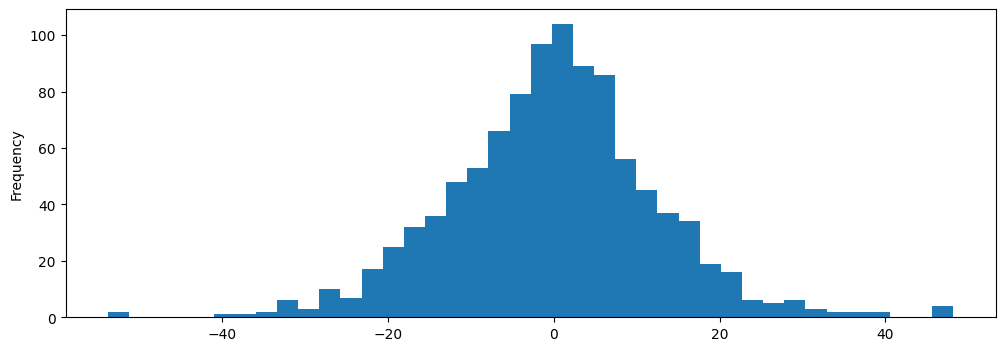

In [204]:
y_train.plot.hist(bins=40, figsize=(12, 4));

Consideriamo una distribuzione normale con media e deviazione standard pari a quelle di `y_train` e generiamo tanti campioni quanti i valori in `y_val`

In [205]:
np.random.seed(42)
random_preds = np.random.normal(
    y_train.mean(),   # centro (media), circa 0
    y_train.std(),    # scala (dev. standard)
    len(y_val)        # numero di campioni
)

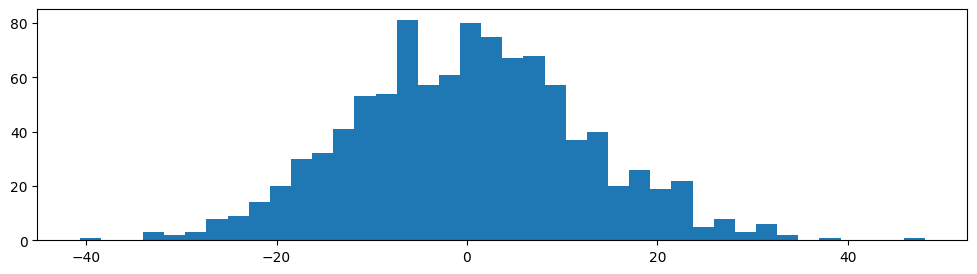

In [206]:
plt.figure(figsize=(12, 3))
plt.hist(random_preds, bins=40);

Valutiamo guadagno e ROI utilizzando i campioni generati al posto delle predizioni del modello

In [207]:
gain(y_val, random_preds)

np.float64(-271.2789306640625)

In [208]:
roi(y_val, random_preds)

np.float64(-0.20801836780762534)

In questo caso otteniamo un valore negativo, ovvero una perdita

### Esercizio 6: Test multipli su modello casuale

Per valutare con maggiore affidabilità l'efficacia di un modello casuale, dobbiamo eseguire test multipli con seed differenti

Calcolare il ROI medio su 1.000 test con predizioni casuali come quello sopra, utilizzando un seed diverso in ciascuna

Si dovrebbe ottenere un ROI medio prossimo allo 0

## Validazione k-fold per serie temporali

Nella cross validation a _k_ fold ordinaria, i dati vengono divisi in _k_ fold mescolati casualmente

Nel caso come questo di una serie temporale, vogliamo però mantenere l'ordine temporale in training e validation set

Come alternativa allo split `KFold`, scikit-learn offre il `TimeSeriesSplit(k)` per questa situazione

- il dataset è diviso in _k_+1 fold contigui di pari dimensioni
- ogni split _i_ da 1 a _k_ contiene i primi _i_ fold come training set e il _i+1_-esimo come validation set

Definiamo un `TimeSeriesSplit` con 3 split

In [209]:
from sklearn.model_selection import TimeSeriesSplit
tss = TimeSeriesSplit(3)

Vediamo ad esempio come suddivide i dati in `X`: gli 8 anni dei dati sono divisi in 4 gruppi da 2

In [210]:
for i, (train, val) in enumerate(tss.split(X), start=1):
    print(f"FOLD {i}")
    train_dates = X.index[train]
    val_dates = X.index[val]
    print(f"Training set da {train_dates.min()} a {train_dates.max()}")
    print(f"Validation set da {val_dates.min()} a {val_dates.max()}")

FOLD 1
Training set da 2001-01-05 00:00:00-05:00 a 2003-01-10 00:00:00-05:00
Validation set da 2003-01-13 00:00:00-05:00 a 2005-01-06 00:00:00-05:00
FOLD 2
Training set da 2001-01-05 00:00:00-05:00 a 2005-01-06 00:00:00-05:00
Validation set da 2005-01-07 00:00:00-05:00 a 2007-01-04 00:00:00-05:00
FOLD 3
Training set da 2001-01-05 00:00:00-05:00 a 2007-01-04 00:00:00-05:00
Validation set da 2007-01-05 00:00:00-05:00 a 2008-12-30 00:00:00-05:00


```
         2001   2002   2003   2004   2005   2006   2007   2008
       +------+------+------+------+------+------+------+------+
Fold 1 |   Training  |  Validation |######## non usato ########|
       +------+------+------+------+------+------+------+------+
Fold 2 |          Training         |  Validation |# non usato #|
       +------+------+------+------+------+------+------+------+
Fold 3 |                 Training                |  Validation |
       +------+------+------+------+------+------+------+------+
```

Per eseguire la cross validation, dobbiamo stabilire anche la metrica di valutazione da utilizzare

Prendiamo come riferimento il ROI, per cui abbiamo implementato la funzione `roi`

Per utilizzarla come metrica al posto di quelle predefinite dobbiamo incapsularla in un oggetto _scorer_ con la funzione `make_scorer`

L'opzione `greater_is_better=True` specifica che valori più alti indicano modelli migliori, al contrario delle misure d'errore

In [211]:
from sklearn.metrics import make_scorer
roi_scorer = make_scorer(roi, greater_is_better=True)

Possiamo ora utilizzare la funzione `cross_validate`, specificando

- il modello da validare
- i dati
- il criterio di suddivisione in fold (oggetto `TimeSeriesSplit`)
- la metrica di valutazione (il ROI)

Usiamo come esempio la regressione lineare semplice

In [212]:
from sklearn.model_selection import cross_validate
cv_results = cross_validate(
    LinearRegression(),
    X, y,
    cv=tss,
    scoring=roi_scorer,
)

Estraiamo i punteggi ottenuti nei tre fold e calcoliamo la media

In [213]:
cv_results["test_score"]

array([-0.14443616,  0.10888946,  0.74112849])

In [214]:
cv_results["test_score"].mean()

np.float64(0.23519392952726648)

Vediamo che il ROI medio è 23,5\%, ma molto variabile da un periodo d'applicazione all'altro, probabilmente anche per via dei training set di diversa durata (2, 4, 6 anni)

Notare che questi ROI sono calcolati su periodi di soli due anni, contro i quattro del validation set fisso usato prima

## Grid search

Possiamo riutilizzare gli stessi componenti della cross validation "semplice" in una grid search per tarare gli iperparametri dei modelli più avanzati

Prendiamo ad esempio come modello base la regressione polinomiale con o senza standardizzazione delle feature generate

In [215]:
model = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scale", None),
    ("regr", LinearRegression())
])

Definiamo la griglia degli iperparametri variabili: applicazione o non della standardizzazione e grado del polinomio (includiamo per confronto anche il grado 1, ovvero la regressione lineare standard)

In [216]:
grid = {
    "scale": [None, StandardScaler()],
    "poly__degree": list(range(1, 7))
}

Creiamo il modello grid search specificando tutti i parametri

- modello base con iperparametri fissi
- griglia dei iperparametri variabili
- criterio di cross validation
- metrica di valutazione

In [217]:
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(model, grid, cv=tss, scoring=roi_scorer)

Addestriamolo quindi su tutti i dati

In [218]:
gs.fit(X, y);

Reperiamo e analizziamo i risultati ottenuti

In [219]:
gs_results = pd.DataFrame(gs.cv_results_)

In [233]:
# stampo le 5 configurazioni migliori
gs_results.sort_values("mean_test_score", ascending=False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_poly__degree,param_scale,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
8,0.020969,0.004834,0.011204,0.000832,5,None,"{'poly__degree': 5, 'scale': None}",-0.042530,0.189004,0.770411,0.305628,0.341974,1
9,0.022822,0.004133,0.012338,0.004096,5,StandardScaler(),"{'poly__degree': 5, 'scale': StandardScaler()}",-0.042530,0.189004,0.770411,0.305628,0.341974,1
0,0.005457,0.001283,0.002818,0.000333,1,None,"{'poly__degree': 1, 'scale': None}",-0.144436,0.108889,0.741128,0.235194,0.372398,3
1,0.004806,0.000391,0.002605,0.000025,1,StandardScaler(),"{'poly__degree': 1, 'scale': StandardScaler()}",-0.144436,0.108889,0.741128,0.235194,0.372398,3
7,0.015386,0.006133,0.008271,0.005226,4,StandardScaler(),"{'poly__degree': 4, 'scale': StandardScaler()}",-0.028171,0.097567,0.272940,0.114112,0.123484,5
6,0.007579,0.000915,0.003903,0.000112,4,None,"{'poly__degree': 4, 'scale': None}",-0.028171,0.097567,0.272940,0.114112,0.123484,5
3,0.006341,0.000310,0.003561,0.000069,2,StandardScaler(),"{'poly__degree': 2, 'scale': StandardScaler()}",-0.128347,0.140300,0.249633,0.087195,0.158813,7
2,0.004257,0.000189,0.002828,0.000297,2,None,"{'poly__degree': 2, 'scale': None}",-0.128347,0.140300,0.249633,0.087195,0.158813,7
10,0.023886,0.002606,0.005505,0.001303,6,None,"{'poly__degree': 6, 'scale': None}",-0.091883,0.055246,0.031052,-0.001861,0.064416,9
11,0.031369,0.012919,0.008034,0.002507,6,StandardScaler(),"{'poly__degree': 6, 'scale': StandardScaler()}",-0.091883,0.055246,0.031052,-0.001861,0.064416,9


Le migliori configurazioni in questo caso sono quelle con le feature di 5° grado (la standardizzazione non fa differenza)

### Esercizio 7: Grid search su kernel ridge

- Effettuare la grid search su un modello kernel ridge
  - con kernel `rbf` con `gamma` pari a $10^{-3},10^{-2},10^{-1}$
  - con peso di regolarizzazione `alpha` pari a $10^{-3},10^{-2},\ldots,10^2$
    - si può usare `np.logspace`
  - con o senza standardizzazione delle feature in ingresso
- Stampare come sopra un frame con le 5 configurazioni migliori

In [222]:
from sklearn.kernel_ridge import KernelRidge

In [234]:
model = KernelRidge(kernel="poly", degree=5, alpha=10)
cross_validate(model, X, y, cv=tss, scoring=roi_scorer)

{'fit_time': array([0.12316537, 0.31173611, 0.44477439]),
 'score_time': array([0.03487253, 0.08827424, 0.08003306]),
 'test_score': array([-0.30935226,  0.03375813, -0.04979757])}

## Aggiunta di variabili predittive

I modelli addestrati sopra sono basati solamente su tre variabili, ovvero i valori di $\Delta_d$ nei tre giorni precedenti a $d$

Non stiamo utilizzando altre informazioni, quali le variazioni dei valori da un giorno all'altro e i massimi/minimi giornalieri

Creiamo un nuovo insieme di variabili che tenga conto di queste altre informazioni

In [223]:
features = {}

Inseriamo inizialmente le feature relative ai valori di $\Delta_d$ nei giorni precedenti, come prima

In [224]:
for n in range(1, 4):   # n da 1 a 3
    features["DeltaLag{}".format(n)] = delta.shift(n)

Per cogliere le variazioni da un giorno all'altro, possiamo considerare le differenze tra valori di una stessa variabile tra giorni consecutivi

Consideriamo ad esempio il valore di apertura $O_d$: possiamo usare come variabile la differenza $O_d-O_{d-1}$ di questo valore da quello del giorno precedente

Anche questa variabile, come $\Delta_d$, è una differenza tra valori piuttosto che un valore assoluto: non viene influenzata dall'andamento di lungo periodo del mercato

Possiamo ottenere questa variabile dalla differenza tra la serie `open` e lo `shift` di se stessa

In [225]:
open_diff = open - open.shift(1)

Visualizziamo alcuni valori di tale variabile, affiancati a quelle da cui è ricavata

In [226]:
pd.DataFrame({
    "Open": open,
    "OpenLag1": open.shift(1),
    "OpenDiff": open_diff
}).head(5)

,Open,OpenLag1,OpenDiff
Date,,,
2001-01-02 00:00:00-05:00,1320.280029,NaN,NaN
2001-01-03 00:00:00-05:00,1283.270020,1320.280029,-37.010010
2001-01-04 00:00:00-05:00,1347.560059,1283.270020,64.290039
2001-01-05 00:00:00-05:00,1333.339966,1347.560059,-14.220093
2001-01-08 00:00:00-05:00,1298.349976,1333.339966,-34.989990


scikit-learn offre un metodo `diff(n)` per ottenere direttamente la differenza tra una serie e il suo `shift(n)`

In [227]:
open.diff()   .head()

,Open
Date,
2001-01-02 00:00:00-05:00,NaN
2001-01-03 00:00:00-05:00,-37.010010
2001-01-04 00:00:00-05:00,64.290039
2001-01-05 00:00:00-05:00,-14.220093
2001-01-08 00:00:00-05:00,-34.989990


Il metodo `equals` permette di verificare che una serie (o frame) sia identica ad un'altra

In [228]:
open.diff() .equals( open - open.shift(1) )

True

Aggiungiamo ad esempio alle feature le differenze da un giorno all'altro dei valori di `high` e `low`, ovvero i massimi e minimi di giornata

- tenere presente che ad ogni giornata $d$ non conosciamo subito $H_d$ e $L_d$, per cui utilizziamo invece $H_{d-1}$ e $L_{d-1}$
- ad es., per ottenere $H_{d-1}-H_{d-2}$, $H_{d-2}-H_{d-3}$ e $H_{d-3}-H_{d-4}$ prendiamo $H_{d}-H_{d-1}$ e applichiamo lo `shift` di 1, 2 e 3 giorni
- _evitiamo quì di usare le differenze $O_d$ e $C_{d-1}$, in quanto in questi dati sono molto correlate a $\Delta_d$_

In [229]:
for n in range(1, 4): # n da 1 a 3
    features["HighDiff{}".format(n)] = high.diff().shift(n)
    features["LowDiff{}".format(n)] = low.diff().shift(n)

Usiamo la funzione `prepare_data` definita sopra per creare il dataset completo con le variabili scelte

In [230]:
X, y = prepare_data(features, delta)

Possiamo visualizzare le prime righe del frame con le variabili generate

In [231]:
X.head(5)

,DeltaLag1,DeltaLag2,DeltaLag3,HighDiff1,LowDiff1,HighDiff2,LowDiff2,HighDiff3,LowDiff3
Date,,,,,,,,,
2001-01-08 00:00:00-05:00,-34.989990,-14.220093,64.290039,-15.469971,-34.190063,2.479980,54.520020,27.479980,-1.430054
2001-01-09 00:00:00-05:00,-2.489990,-34.989990,-14.220093,-36.420044,-18.659912,-15.469971,-34.190063,2.479980,54.520020
2001-01-10 00:00:00-05:00,4.940063,-2.489990,-34.989990,13.369995,18.849976,-36.420044,-18.659912,-15.469971,-34.190063
2001-01-11 00:00:00-05:00,12.469971,4.940063,-2.489990,2.040039,-7.859985,13.369995,18.849976,-36.420044,-18.659912
2001-01-12 00:00:00-05:00,13.549927,12.469971,4.940063,18.429932,22.439941,2.040039,-7.859985,13.369995,18.849976


### Esercizio 8: Test modelli con nuove feature

- **(8a)** Addestrare sui nuovi dati un modello di regressione lasso con $\alpha=3$ e verificare quali feature non vengono escluse
- **(8b)** Eseguire la cross validation di un modello di regressione lineare semplice, con gli stessi criteri di suddivisione dati e valutazione usati sopra
- **(8c)** Eseguire la grid search degli iperparametri di un modello kernel ridge, usando le stesse specifiche dell'esercizio 7

In [235]:
from sklearn.linear_model import Lasso

In [237]:
model = Lasso(alpha=3)
model.fit(X, y)

Lasso(alpha=3)

In [238]:
pd.Series(model.coef_, index=X.columns)

,0
DeltaLag1,-0.051997
DeltaLag2,-0.039001
DeltaLag3,0.043048
HighDiff1,0.000000
LowDiff1,-0.051650
HighDiff2,-0.007102
LowDiff2,-0.000000
HighDiff3,0.000000
LowDiff3,-0.028046


In [239]:
cross_validate(
    LinearRegression(),
    X, y,
    cv=TimeSeriesSplit(3),
    scoring=roi_scorer,
)

{'fit_time': array([0.00537753, 0.00439692, 0.04066205]),
 'score_time': array([0.00343013, 0.00307322, 0.01085567]),
 'test_score': array([ 0.04231903, -0.10271079,  0.60356483])}

In [246]:
model = KernelRidge(kernel="poly", alpha=1)
grid = {
    "degree": range(2,6)
}
gs = GridSearchCV(model, grid, cv=TimeSeriesSplit(3), scoring=roi_scorer)
gs.fit(X, y);

In [247]:
pd.DataFrame(gs.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_degree,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.144772,0.024352,0.025595,0.015033,2,{'degree': 2},0.000714,-0.106237,0.451613,0.115363,0.241740,1
1,0.143184,0.084359,0.030738,0.012044,3,{'degree': 3},0.130632,-0.084433,-0.176219,-0.043340,0.128597,3
2,0.127133,0.082791,0.045131,0.023949,4,{'degree': 4},-0.389534,-0.003049,0.262983,-0.043200,0.267898,2
3,0.130337,0.085483,0.040962,0.007750,5,{'degree': 5},-0.309352,0.033758,-0.088653,-0.121416,0.141977,4


## Esercizi avanzati suggeriti

- Testare modelli con l'aggiunta di nuove feature non considerate quì, ad es. le differenze tra valori massimi e minimi nei giorni precedenti
- Cambiare il protocollo di trading in modo che venga svolta un'operazione di acquisto/vendita solo se il valore assoluto di $\hat{\Delta}_d$ supera una determinata soglia (per cui c'è più certezza di un rialzo/ribasso) e verificare come varia il ROI al variare di tale soglia
- Eseguire test su periodi differenti e/o con titoli/indici differenti